## Requirement

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch

# Check if a GPU (CUDA) is available in this Colab runtime
gpu_available = torch.cuda.is_available()

if gpu_available:
    device = "cuda"
    print(f"GPU Detected: {torch.cuda.get_device_name(0)}")
else:
    device = "cpu"
    print("No GPU detected. Using CPU")

GPU Detected: Tesla T4


In [3]:

%pip install -r ../requirement.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: '../requirement.txt'


## Loading Datasets

In [4]:
import kagglehub

# Download latest version
db1 = kagglehub.dataset_download("alessandrasala79/ai-vs-human-generated-dataset")

print("Path to dataset files:", db1)

# Download latest version
db2 = kagglehub.dataset_download("doctorstrange420/real-and-fake-ai-generated-art-images-dataset")

print("Path to dataset files:", db2)

Using Colab cache for faster access to the 'ai-vs-human-generated-dataset' dataset.
Path to dataset files: /kaggle/input/ai-vs-human-generated-dataset
Using Colab cache for faster access to the 'real-and-fake-ai-generated-art-images-dataset' dataset.
Path to dataset files: /kaggle/input/real-and-fake-ai-generated-art-images-dataset


In [ ]:
import pandas as pd
import os
import numpy as np
from PIL import Image
from pathlib import Path
import random

def load_dataset(image_folder, labels_path = None, img_size = (380,380), csv = False, csv_head = ['file_name', 'label'], custom_heading = {}, limit = None, shuffle = True, random_seed = 42):
    # 1. Create a mapping dictionary
    # We transform 'train_data/abc.jpg' -> 'abc.jpg' using os.path.basename
    label_map = {}
    img_paths = []

    if(labels_path is None):
      for label_dir in os.listdir(image_folder):
        img_labels = os.path.basename(label_dir)
        img_path = os.path.join(image_folder, label_dir)
        for img_name in os.listdir(img_path):
            img_paths.append(os.path.join(img_path, img_name))
            label_map[img_name] = img_labels

    if(csv):
      df_labels = pd.read_csv(labels_path)

      for _, row in df_labels.iterrows():
          # Replace 'id' and 'label' with the actual column names in your CSV
          full_name_in_label = row[csv_head[0]]
          clean_name = os.path.basename(full_name_in_label)
          label_map[clean_name] = str(row[csv_head[1]])
          img_paths.append(os.path.join(image_folder, full_name_in_label))


    images = []
    labels = []

    if(custom_heading):
      for key, value in label_map.items():
        if value in custom_heading.keys():
          label_map[key] = custom_heading[value]

    if(shuffle):
      random.Random(random_seed).shuffle(img_paths)


    if limit is not None:
      img_paths = img_paths[:limit]

    print(f"Mapping created for {len(label_map)} entries.")
    # Example lookup:
    example_key = list(label_map.keys())[0]
    print(f"Example: Filename '{example_key}' maps to label '{label_map[example_key]}'")

    for img in img_paths:

          # (Add your image loading logic here, e.g., PIL or cv2)
          filename = os.path.basename(img)
          # Load image using PIL
          img_obj = Image.open(img)
          # Convert to target mode if needed
          if img_obj.mode != 'RGB':
              img_obj = img_obj.convert('RGB')
          # Resize
          img_obj= img_obj.resize(img_size)
          # Convert to numpy array
          img_array = np.array(img_obj,dtype=np.uint8)
          images.append(img_array)
          labels.append(label_map[filename])

    images = np.array(images)
    labels = np.array(labels)

    print("Datasets Loaded!")
    return images, labels



In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


# Using the function
images1, labels1 = load_dataset("/kaggle/input/real-and-fake-ai-generated-art-images-dataset/Data", custom_heading = {"FAKE": 1, "REAL": 0}, limit = 1000)
print("DATA in images1: ", images1)
print("DATA in labels1: ", labels1)
print(f"Image shape of images1: {images1.shape}")
print(f"Label shape of labels1: {labels1.shape}")
images2, labels2 = load_dataset(db1, labels_path = "/kaggle/input/ai-vs-human-generated-dataset/train.csv", csv = True, limit = 1000)
print("DATA in images2: ", images2)
print("DATA in labels2: ", labels2)

images = np.concatenate([images1, images2], axis=0)

# Combine the label arrays
labels = np.concatenate([labels1, labels2], axis=0)

print(f"Combined Images Shape: {images.shape}")
print(f"Combined Labels Shape: {labels.shape}")

# Split into train/test (0.2 = train 80% : test 20% split)
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)
print(X_train)
print(y_train)

Mapping created for 21642 entries.
Example: Filename 'img012954.jpg' maps to label '1'
Datasets Loaded!
DATA in images1:  [[[[ 44  56  36]
   [ 56  68  46]
   [ 55  68  45]
   ...
   [ 42  54  40]
   [ 42  54  42]
   [ 33  45  33]]

  [[ 45  56  38]
   [ 51  63  43]
   [ 48  60  37]
   ...
   [ 32  44  30]
   [ 37  48  36]
   [ 33  45  34]]

  [[ 48  59  43]
   [ 46  58  38]
   [ 37  49  27]
   ...
   [ 20  32  18]
   [ 29  40  28]
   [ 31  43  31]]

  ...

  [[116  84  43]
   [116  86  46]
   [115  86  46]
   ...
   [110  92  54]
   [107  90  52]
   [105  90  51]]

  [[110  77  36]
   [112  81  40]
   [112  83  42]
   ...
   [113  97  58]
   [107  91  52]
   [103  88  49]]

  [[107  73  34]
   [110  80  38]
   [111  82  40]
   ...
   [114  99  60]
   [106  91  52]
   [101  86  47]]]


 [[[ 91  64  34]
   [ 92  65  37]
   [ 99  74  47]
   ...
   [140 123  94]
   [136 119  89]
   [137 120  90]]

  [[ 91  64  34]
   [ 92  65  37]
   [ 99  74  47]
   ...
   [141 124  94]
   [137 120  90]


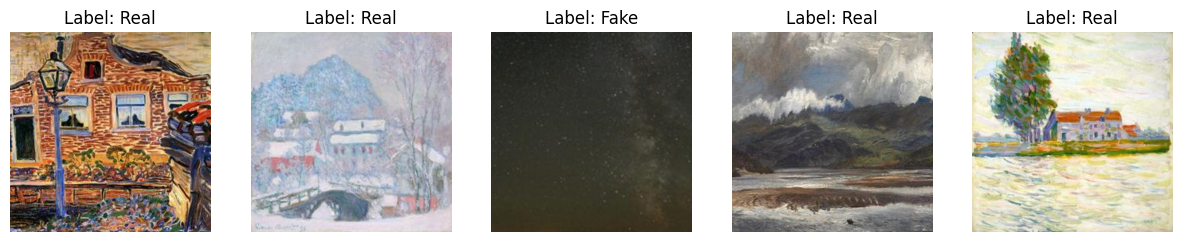

In [39]:
import matplotlib.pyplot as plt

# Let's look at the first 5 images in X_train
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train[i])

    # The shortcut version:
    # We convert y_train[i] to int just in case it's a string '1' or '0'
    label_word = 'Real' if int(y_train[i]) == 0 else 'Fake'

    plt.title(f"Label: {label_word}")
    plt.axis('off')
plt.show()

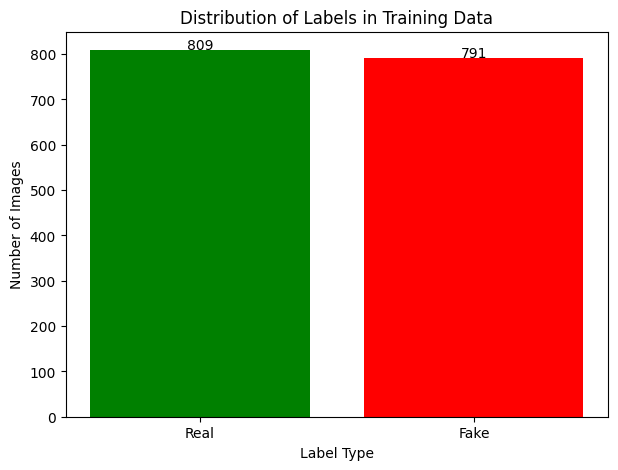

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Count the occurrences of each label
# unique: [0, 1], counts: [number of 0s, number of 1s]
unique, counts = np.unique(y_train, return_counts=True)

# 2. Map the numeric labels to names for the graph
label_names = ['Real' if int(u) == 0 else 'Fake' for u in unique]

# 3. Create the Bar Graph
plt.figure(figsize=(7, 5))
plt.bar(label_names, counts, color=['green', 'red'])

# 4. Add decorations
plt.title("Distribution of Labels in Training Data")
plt.xlabel("Label Type")
plt.ylabel("Number of Images")

# Optional: Add the exact count numbers on top of the bars
for i, count in enumerate(counts):
    plt.text(i, count + 1, str(count), ha='center')

plt.show()

In [41]:
import torch

# 1. Define the device (we already have this from your earlier cell)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# 2. Convert NumPy arrays to PyTorch Tensors and move to GPU
# Note: We convert to float and normalize by 255 for typical model training
X_train = torch.from_numpy(X_train).float().to(device)
y_train_gpu = torch.tensor(y_train.astype(int)).to(device)

print(f"X_train device: {X_train.device}")
print(f"X_train shape: {X_train.shape}")

Using device: cuda
X_train device: cuda:0
X_train shape: torch.Size([1600, 380, 380, 3])


## Pre-processing

#### Load Images for Model Training


In [ ]:
# import numpy as np
# from PIL import Image
# from pathlib import Path
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import LabelEncoder

# def load_images_from_folder(dataset_path, image_size=(224, 224), target_mode=None):

#     """
#     Load images and labels from a folder structure where each subfolder is a class.
#     Automatically detects image modes and converts to a consistent format.

#     Args:
#         dataset_path: Path to the dataset folder (e.g., '../assets/dataset')
#         image_size: Tuple for resizing images (width, height) | Default: (224,224)
#         target_mode: Target color mode ('RGB', 'L', or None for auto-detection) | Default: None

#     Returns:
#         images: Numpy array of images
#         labels: Numpy array of encoded labels (it got number label from LabelEncoder. {Ex. labels = [1,2,3,2,1,3...]})
#         label_encoder: Fitted LabelEncoder for decoding predictions(it knows what 0 or 1 represent. {Ex. Cat = 0, Dog = 1})
#     """

#     images = []
#     labels = []
#     # The set() function create a list and make sure that every items are unique
#     detected_modes = set()
#     detected_format = set()
#     dataset_path = Path(dataset_path)

#     # Define the extensions you want to find
#     valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

#     # First pass: detect modes
#     for label_dir in dataset_path.iterdir():
#         if label_dir.is_dir():
#             for img_path in label_dir.glob('*'):
#                 if img.suffix.lower() in valid_extensions:
#                     detected_format.add(img_path.suffix.lower())
#                     try:
#                         with Image.open(img_path) as img:
#                             detected_modes.add(img.mode)
#                             # Load image using PIL
#                             img = Image.open(img_path)
#                             # Convert to target mode if needed
#                             if img.mode != target_mode:
#                                 img = img.convert(target_mode)
#                             # Resize
#                             img = img.resize(image_size)
#                             # Convert to numpy array
#                             img_array = np.array(img)
#                             images.append(img_array)
#                             labels.append(label)
#                     except Exception as e:
#                         print(f"Error detecting mode for {img_path}: {e}")


#     print(f"File Formats: {detected_format}")


#     # Convert to numpy arrays for better calculation speed and utilities
#     images = np.array(images)
#     labels = np.array(labels)

#     # Encode labels {LabelEncoder will look at all of the unique items in a List and assign it a number}
#     label_encoder = LabelEncoder()
#     labels_encoded = label_encoder.fit_transform(labels)

#     # Print what just processed
#     print(f"Loaded {len(images)} images with {len(label_encoder.classes_)} classes: {list(label_encoder.classes_)}")
#     print(f"Final image shape: {images.shape}")

#     return images, labels_encoded, label_encoder

# # Using the function
# images, labels, label_encoder = load_images_from_folder('../assets/dataset')

# # Split into train/test (0.2 = train 80% : test 20% split)
# X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)


## Load Models

#### EfficientNet B4

In [ ]:
from urllib.request import urlopen
from PIL import Image
import timm

img = Image.open(urlopen(
    'https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/beignets-task-guide.png'
))

EfficientNet_B4 = timm.create_model(
    'efficientnet_b4.ra2_in1k',
    pretrained=True,
    features_only=True,
)

print(EfficientNet_B4)
# EfficientNet_B4 = EfficientNet_B4.eval()

# # get EfficientNet_B4 specific transforms (normalization, resize)
# data_config = timm.data.resolve_model_data_config(EfficientNet_B4)
# transforms = timm.data.create_transform(**data_config, is_training=False)

# output = EfficientNet_B4(transforms(img).unsqueeze(0))  # unsqueeze single image into batch of 1

# for o in output:
#     # print shape of each feature map in output
#     # e.g.:
#     #  torch.Size([1, 24, 160, 160])
#     #  torch.Size([1, 32, 80, 80])
#     #  torch.Size([1, 56, 40, 40])
#     #  torch.Size([1, 160, 20, 20])
#     #  torch.Size([1, 448, 10, 10])

#     print(o.shape)


#### VIT

In [ ]:
from transformers import ViTImageProcessor, ViTModel
from PIL import Image
import requests

url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw)

processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')
ViT = ViTModel.from_pretrained('google/vit-base-patch16-224-in21k')
inputs = processor(images=image, return_tensors="pt")

outputs = ViT(**inputs)
last_hidden_states = outputs.last_hidden_state


## Training

In [ ]:
import torch
import torch.nn as nn

class FeatureMapToViT(nn.Module):
    def __init__(self, vit_model, num_classes=2):
        super().__init__()
        self.vit = vit_model

        # Linear projection: flatten feature map → ViT input size
        # 448 * 10 * 10 = 44,800 → 3 * 224 * 224 = 150,528
        self.feature_to_image = nn.Linear(448 * 10 * 10, 3 * 224 * 224)

        # Classification head
        self.classifier = nn.Linear(768, num_classes)

    def forward(self, efficientnet_features):
        # efficientnet_features shape: (batch, 448, 10, 10)

        # Step 1: Flatten
        batch_size = efficientnet_features.shape[0]
        flattened = torch.flatten(efficientnet_features, 1)
        # Shape: (batch, 44800)

        # Step 2: Linear projection to image space
        projected = self.feature_to_image(flattened)
        # Shape: (batch, 150528)

        # Step 3: Reshape to image format
        image_features = projected.reshape(batch_size, 3, 224, 224)
        # Shape: (batch, 3, 224, 224)

        # Step 4: Pass through ViT
        vit_outputs = self.vit(image_features)
        vit_features = vit_outputs.last_hidden_state[:, 0]  # CLS token
        # Shape: (batch, 768)

        # Step 5: Classify
        logits = self.classifier(vit_features)
        # Shape: (batch, num_classes)

        return logits


# Full pipeline
class HybridPipeline(nn.Module):
    def __init__(self, efficientnet_model, vit_model, transforms, num_classes=2):
        super().__init__()
        self.efficientnet = efficientnet_model
        self.vit_pipeline = FeatureMapToViT(vit_model, num_classes)
        self.transforms = transforms

    def forward(self, image):
        # Get EfficientNet features
        eff_features = self.efficientnet(self.transforms(image).unsqueeze(0))
        eff_last = eff_features[-1]  # (batch, 448, 10, 10)

        # Feed to ViT through linear projection
        logits = self.vit_pipeline(eff_last)

        return logits


# Training
model = HybridPipeline(efficientnet_model, vit_model, transforms, num_classes=2)

optimizer = torch.optim.AdamW(model.vit_pipeline.parameters(), lr=1e-4, weight_decay=0.01)
loss_fn = torch.nn.CrossEntropyLoss()

for epoch in range(num_epochs):
    for batch_images, batch_labels in train_loader:
        logits = model(batch_images)
        loss = loss_fn(logits, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()